# Exploratory Data Analysis & Conversion Analysis

## Objective

After validating data quality and randomization integrity, the next step is to analyze conversion behavior across experiment groups.

Key Questions:

1. What is the conversion rate for each group?
2. Which group performs better?
3. What is the raw conversion lift?
4. Is the difference large enough to matter from a business perspective?

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.proportion import proportion_confint

pd.set_option("display.max_columns", None)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [5]:
df = pd.read_csv("../data/marketing_AB.csv")

df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

df = df.drop(columns=["unnamed:_0"])

print("Dataset Loaded Successfully")
print(df.shape)

Dataset Loaded Successfully
(588101, 6)


In [6]:
conversion_summary = (
    df.groupby("test_group")["converted"]
      .agg(
          users="count",
          conversions="sum"
      )
)

conversion_summary

,users,conversions
test_group,,
ad,564577,14423
psa,23524,420


In [7]:
conversion_summary["conversion_rate"] = (
    conversion_summary["conversions"]
    / conversion_summary["users"]
)

conversion_summary

,users,conversions,conversion_rate
test_group,,,
ad,564577,14423,0.025547
psa,23524,420,0.017854


In [8]:
conversion_summary["conversion_rate"] = (
    conversion_summary["conversion_rate"] * 100
).round(3)

conversion_summary

,users,conversions,conversion_rate
test_group,,,
ad,564577,14423,2.555
psa,23524,420,1.785


In [9]:
ad_rate = conversion_summary.loc["ad", "conversion_rate"]
psa_rate = conversion_summary.loc["psa", "conversion_rate"]

absolute_difference = ad_rate - psa_rate

raw_lift = (
    absolute_difference
    / psa_rate
) * 100

print(f"Ad Conversion Rate: {ad_rate:.3f}%")
print(f"PSA Conversion Rate: {psa_rate:.3f}%")
print(f"Absolute Difference: {absolute_difference:.3f}%")
print(f"Raw Lift: {raw_lift:.2f}%")

Ad Conversion Rate: 2.555%
PSA Conversion Rate: 1.785%
Absolute Difference: 0.770%
Raw Lift: 43.14%


## Initial Business Insight

The advertising campaign achieved a conversion rate of approximately 2.56%, compared with 1.79% for the PSA group.

This represents an absolute improvement of approximately 0.77 percentage points and a relative lift of approximately 43%.

While this appears economically meaningful, statistical testing is required before concluding that the observed difference is attributable to the advertising campaign rather than random variation.

In [10]:
plot_df = conversion_summary.reset_index()

plot_df

,test_group,users,conversions,conversion_rate
0,ad,564577,14423,2.555
1,psa,23524,420,1.785


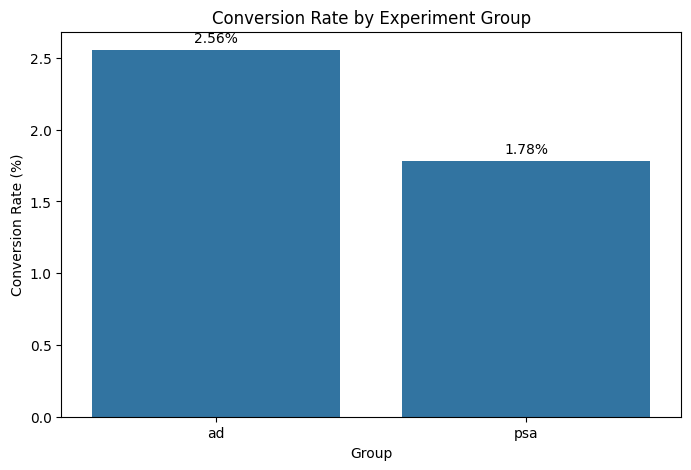

In [12]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=plot_df,
    x="test_group",
    y="conversion_rate"
)

for i, value in enumerate(plot_df["conversion_rate"]):
    ax.text(
        i,
        value + 0.05,
        f"{value:.2f}%",
        ha="center"
    )

plt.title("Conversion Rate by Experiment Group")
plt.xlabel("Group")
plt.ylabel("Conversion Rate (%)")

plt.show()

In [13]:
sample_df = df.sample(
    50000,
    random_state=42
)

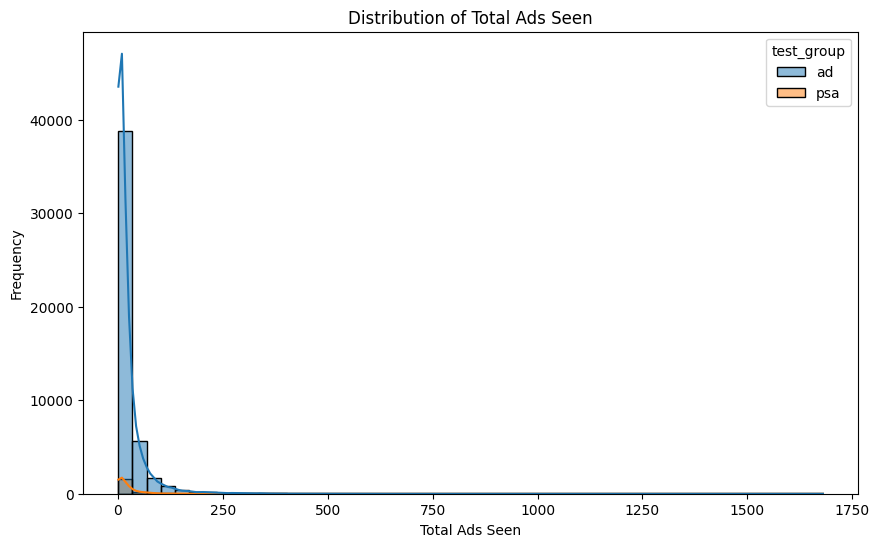

In [14]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=sample_df,
    x="total_ads",
    hue="test_group",
    bins=50,
    kde=True
)

plt.title("Distribution of Total Ads Seen")
plt.xlabel("Total Ads Seen")
plt.ylabel("Frequency")

plt.show()

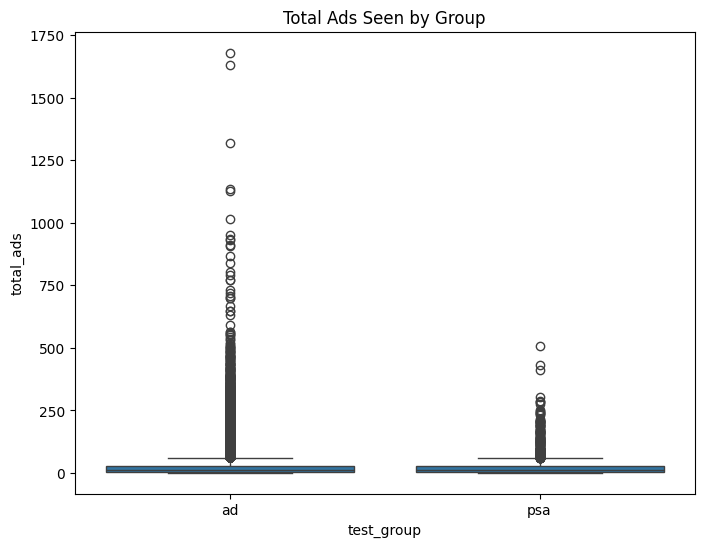

In [15]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=sample_df,
    x="test_group",
    y="total_ads"
)

plt.title("Total Ads Seen by Group")

plt.show()

## Exploratory Analysis Findings

### Conversion Performance

- Ad Group Conversion Rate: 2.555%
- PSA Group Conversion Rate: 1.785%
- Absolute Difference: 0.770 percentage points
- Relative Lift: 43.1%

### Initial Observation

The advertising campaign demonstrates substantially higher conversion performance than the PSA group.

However, conversion differences alone are insufficient for decision making.

The next phase applies formal statistical testing to determine whether the observed lift is statistically significant and unlikely to have occurred by chance.